In [39]:
from pathlib import Path
import subprocess
import os
from pydriller import Repository
AUTOR = "atom"
PROJETO = "atom"
URL = f"https://github.com/{AUTOR}/{PROJETO}"
REPO = Path(f"../data/{PROJETO}")

In [40]:
if not REPO.exists():
    os.mkdir(REPO)

In [41]:
subprocess.run(
    ["git", "clone", "--depth", "500", URL, str(REPO)]
)

Cloning into '../data/atom'...


CompletedProcess(args=['git', 'clone', '--depth', '500', 'https://github.com/atom/atom', '../data/atom'], returncode=0)

In [42]:
dados = []
for commit in Repository(str(REPO)).traverse_commits():
    try:
        for arquivo in commit.modified_files:
            caminho = arquivo.new_path or arquivo.old_path
            dados.append(
                {
                    "commit":commit.hash,
                    "data_commit": commit.author_date,
                    "autor":commit.author.name,
                    "arquivo": caminho,
                    "linhas_add": arquivo.added_lines,
                    "linhas_removidas": arquivo.deleted_lines
                }
                
            )
    except:
        print("skipping")

skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping
skipping


In [43]:
print(dados[0])

{'commit': '0f1d1556851dc8e74aa9278830c0b6ee08d1d1d0', 'data_commit': datetime.datetime(2014, 7, 22, 15, 21, 41, tzinfo=<git.objects.util.tzoffset object at 0x7fa18eef9fa0>), 'autor': 'Ben Ogle', 'arquivo': 'spec/editor-component-spec.coffee', 'linhas_add': 21, 'linhas_removidas': 1}


In [34]:
import pandas as pd
df = pd.DataFrame(dados)

In [38]:
print("Numero de modificacoes em arquivos: ", len(df))
print("Numero commits: ", df["commit"].nunique())
print("Numero contribuidores: ", df["autor"].nunique())

Numero de modificacoes em arquivos:  2533
Numero commits:  1386
Numero contribuidores:  298


In [44]:
frequencia = (
    df.groupby("arquivo")
      .size()
      .reset_index(name="modificacoes")
      .sort_values("modificacoes", ascending=False)
)

frequencia.head(10)

,arquivo,modificacoes
42,README.md,173
273,tests/test_requests.py,90
217,setup.py,80
81,docs/index.rst,75
84,docs/user/advanced.rst,70
64,docs/_templates/sidebarintro.html,68
212,requests/utils.py,65
35,HISTORY.rst,65
65,docs/_templates/sidebarlogo.html,62
38,Makefile,61


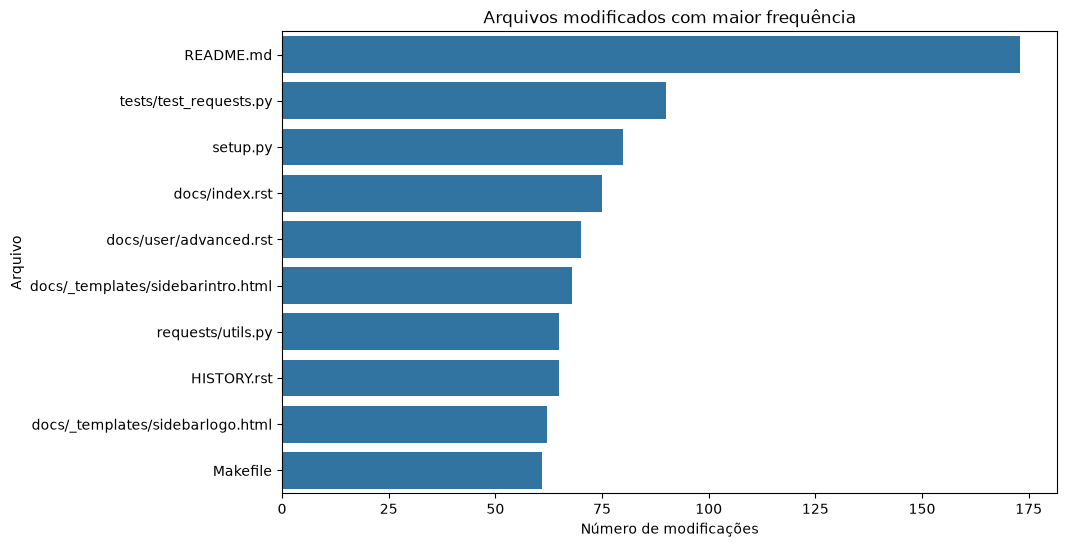

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = frequencia.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top10,
    x="modificacoes",
    y="arquivo"
)

plt.title("Arquivos modificados com maior frequência")
plt.xlabel("Número de modificações")
plt.ylabel("Arquivo")
plt.show()

In [48]:
df["churn"] = (
    df["linhas_add"]
    + df["linhas_removidas"]
)

In [49]:
churn = (
    df.groupby("arquivo")["churn"]
      .sum()
      .reset_index()
      .sort_values("churn", ascending=False)
)

churn.head(10)

,arquivo,churn
172,requests/packages/idna/uts46data.py,8001
113,requests/cacert.pem,5817
41,Pipfile.lock,5443
170,requests/packages/idna/idnadata.py,4704
273,tests/test_requests.py,3454
34,HISTORY.md,2206
35,HISTORY.rst,1913
184,requests/packages/urllib3/contrib/securetransp...,1616
276,tests/test_utils.py,1351
204,requests/packages/urllib3/util/selectors.py,1286


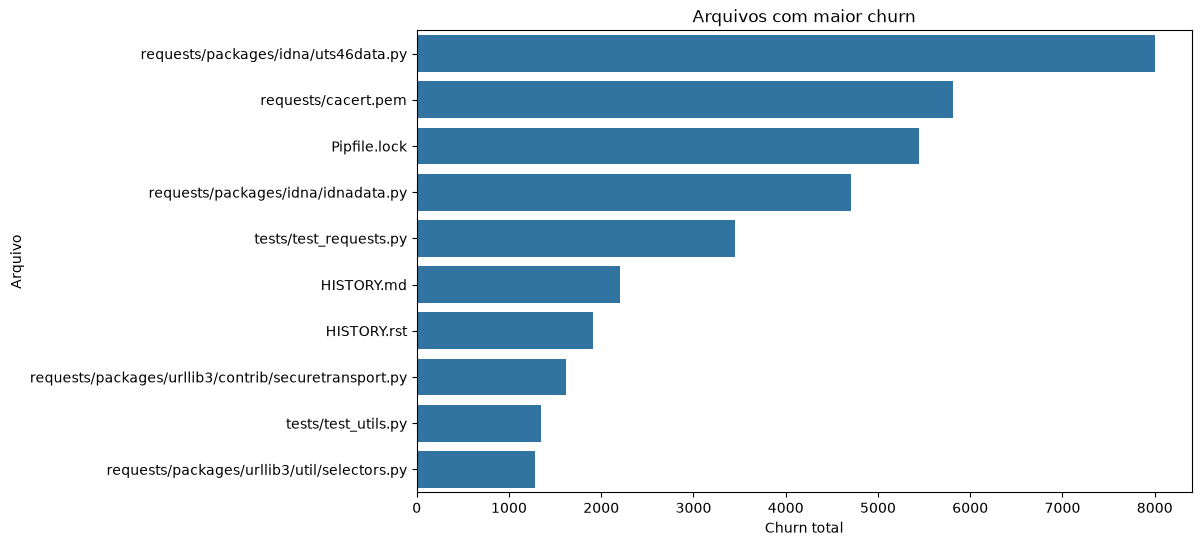

In [50]:
top_churn = churn.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_churn,
    x="churn",
    y="arquivo"
)

plt.title("Arquivos com maior churn")
plt.xlabel("Churn total")
plt.ylabel("Arquivo")
plt.show()